# 03 — End-to-end Curriculum Check (real data, tiny model)

In [1]:
import re, json, tempfile, random
import numpy as np
from pathlib import Path
from collections import Counter

from influence_curriculum.data import DataConfig, load_documents

DATA_DIR = "../datasets/BabyLM-2026-Strict-Small"

# --- same segmentation rules as nb01 ---
def segment_childes(text):
    docs = []
    for line in text.splitlines():
        if re.match(r'^\[', line.strip()):
            continue
        line = re.sub(r'^\*[A-Z]+:\t', '', line)
        line = re.sub(r'\[.*?\]', '', line).strip()
        if line:
            docs.append(line)
    return docs

def segment_simple_wiki(text):
    docs, current = [], []
    for line in text.splitlines():
        if re.match(r'^= = =', line.strip()):
            if current:
                docs.append(' '.join(current))
            title = re.sub(r'= = =', '', line).strip()
            current = [title] if title else []
        elif line.strip():
            current.append(line.strip())
    if current:
        docs.append(' '.join(current))
    return docs

cfg = DataConfig(
    doc_boundary={
        "childes.train.txt": segment_childes,
        "simple_wiki.train.txt": segment_simple_wiki,
    },
    default_boundary="line",
    min_doc_tokens=3,
)

texts_all, ids_all = load_documents(DATA_DIR, cfg)
print(f"Full dataset: {len(texts_all):,} docs")
counts = Counter(i.split("#")[0] for i in ids_all)
for src, n in sorted(counts.items()):
    print(f"  {src:30s}: {n:6d} docs")

/Users/adrian.rojas/dev/babylm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Full dataset: 726,009 docs
  bnc_spoken.train              :  48831 docs
  childes.train                 : 302745 docs
  gutenberg.train               :  56991 docs
  open_subtitles.train          : 300588 docs
  simple_wiki.train             :  14790 docs
  switchboard.train             :   2064 docs


In [2]:
# Subsample proportionally per source — 10% of the full corpus
# On CPU with tiny-gpt2 this takes ~15-20 min; use device="mps" or "cuda" to speed up
SAMPLE_FRAC = 0.02
N_SAMPLE = round(len(texts_all) * SAMPLE_FRAC)
rng = random.Random(42)

paired = list(zip(texts_all, ids_all))
by_source = {}
for t, i in paired:
    src = i.split("#")[0]
    by_source.setdefault(src, []).append((t, i))

sampled = []
for src, items in sorted(by_source.items()):
    n = max(1, round(N_SAMPLE * len(items) / len(texts_all)))
    sampled.extend(rng.sample(items, min(n, len(items))))

rng.shuffle(sampled)
sampled = sampled[:N_SAMPLE]
texts, doc_ids = zip(*sampled)
texts, doc_ids = list(texts), list(doc_ids)

src_counts = Counter(i.split("#")[0] for i in doc_ids)
print(f"Subsample: {len(texts):,} docs ({100*SAMPLE_FRAC:.0f}% of full corpus)")
for src, n in sorted(src_counts.items()):
    print(f"  {src:30s}: {n:6d} docs ({100*n/len(texts):.1f}%)")

Subsample: 14,520 docs (2% of full corpus)
  bnc_spoken.train              :    976 docs (6.7%)
  childes.train                 :   6055 docs (41.7%)
  gutenberg.train               :   1140 docs (7.9%)
  open_subtitles.train          :   6012 docs (41.4%)
  simple_wiki.train             :    296 docs (2.0%)
  switchboard.train             :     41 docs (0.3%)


In [3]:
# Compute Phi with tiny-gpt2 (T=2 checkpoints: epoch 0 and epoch 1)
# This trains for 2 mini-epochs on the subsample — takes ~2-3 min on CPU
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from influence_curriculum.train import TrainingConfig, train_surrogate
from influence_curriculum.score import InfluenceConfig, compute_influence_matrix

# MODEL = "sshleifer/tiny-gpt2"
MODEL = "BabyLM-community/BabyLM-2026-Baseline-GPT2-Strict-Small"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL)

out_dir = tempfile.mkdtemp()

train_cfg = TrainingConfig(
    epochs=2,
    per_device_batch_size=8,
    effective_batch_size=8,   # no grad accumulation for speed
    max_seq_len=64,           # short for CPU speed
    lr_scheduler="cosine",
)

print("Phase 1: training surrogate...")
ckpt_paths = train_surrogate(model, tokenizer, texts, out_dir, train_cfg, seed=0, device="cpu")
print(f"  checkpoints: {[Path(p).name for p in ckpt_paths]}")

print("Phase 2: computing influence matrix...")
encodings = [tokenizer(t, truncation=True, max_length=64, return_tensors="pt") for t in texts]
Phi = compute_influence_matrix(ckpt_paths, encodings, InfluenceConfig(), device="cpu")
print(f"  Phi shape: {Phi.shape}  (expected {len(texts)} x {len(ckpt_paths)})")
print(f"  score range: [{Phi.min():.4f}, {Phi.max():.4f}]  mean: {Phi.mean():.4f}")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 57787.84it/s]


Phase 1: training surrogate...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 15.89it/s]


  checkpoints: ['epoch_00', 'epoch_01']
Phase 2: computing influence matrix...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 9437.58it/s]


  Phi shape: (14520, 2)  (expected 14520 x 2)
  score range: [-0.0728, 0.1664]  mean: 0.0270


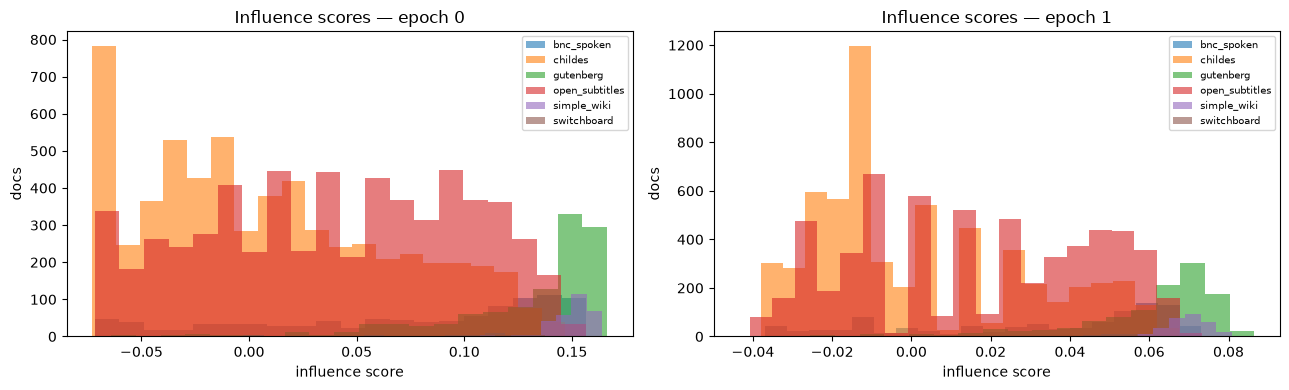

In [4]:
# Score distribution per source — do sources separate in influence space?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of scores epoch 0, coloured by source
sources = sorted(src_counts.keys())
colors = plt.cm.tab10.colors
for t_idx, ax in enumerate(axes):
    for color, src in zip(colors, sources):
        mask = [i.startswith(src) for i in doc_ids]
        scores = Phi[mask, t_idx]
        ax.hist(scores, bins=20, alpha=0.6, label=src.replace('.train',''), color=color)
    ax.set_title(f'Influence scores — epoch {t_idx}')
    ax.set_xlabel('influence score')
    ax.set_ylabel('docs')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [5]:
# Phase 3: build curriculum and verify permutation validity
from influence_curriculum.curriculum import CurriculumConfig, build_curriculum

curr_dir = tempfile.mkdtemp()
build_curriculum(Phi, texts, doc_ids, CurriculumConfig(), curr_dir, seed=0)

T = Phi.shape[1]
print("Permutation check:")
for e in range(T):
    path = Path(curr_dir) / "curriculum" / f"epoch_{e:02d}.jsonl"
    ids_out = [json.loads(l)["id"] for l in path.read_text().splitlines()]
    ok = sorted(ids_out) == sorted(doc_ids)
    print(f"  epoch {e:02d}: {len(ids_out)} docs  is_permutation={ok}")

Permutation check:
  epoch 00: 14520 docs  is_permutation=True
  epoch 01: 14520 docs  is_permutation=True


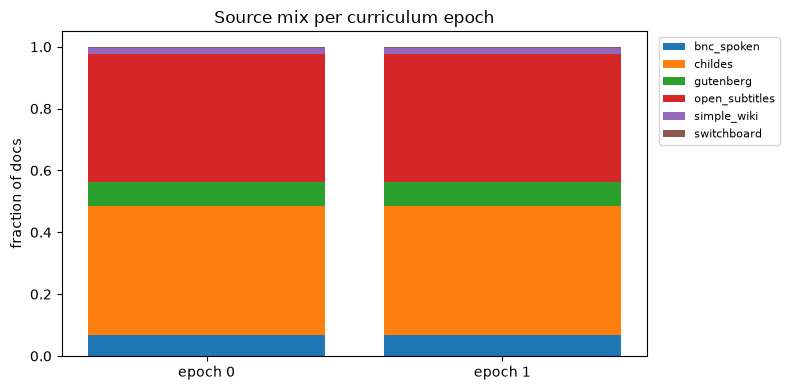


First 10 doc sources per epoch (shows grouping effect):
  epoch 0: ['childes', 'childes', 'bnc_spoken', 'childes', 'childes', 'open_subtitles', 'open_subtitles', 'open_subtitles', 'bnc_spoken', 'open_subtitles']
  epoch 1: ['childes', 'childes', 'childes', 'bnc_spoken', 'open_subtitles', 'childes', 'childes', 'open_subtitles', 'open_subtitles', 'childes']


In [6]:
# Source mix per epoch — does influence sorting shift the source distribution?
source_mix = []
for e in range(T):
    path = Path(curr_dir) / "curriculum" / f"epoch_{e:02d}.jsonl"
    ids_out = [json.loads(l)["id"] for l in path.read_text().splitlines()]
    source_mix.append(Counter(i.split("#")[0] for i in ids_out))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(T)
bottom = np.zeros(T)
for color, src in zip(colors, sources):
    vals = np.array([m.get(src, 0) / len(doc_ids) for m in source_mix])
    ax.bar(x, vals, bottom=bottom, label=src.replace('.train',''), color=color)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"epoch {e}" for e in range(T)])
ax.set_ylabel("fraction of docs")
ax.set_title("Source mix per curriculum epoch")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print the actual ordering of the first 20 docs in each epoch
print("\nFirst 10 doc sources per epoch (shows grouping effect):")
for e in range(T):
    path = Path(curr_dir) / "curriculum" / f"epoch_{e:02d}.jsonl"
    ids_out = [json.loads(l)["id"] for l in path.read_text().splitlines()]
    srcs = [i.split("#")[0].replace(".train","") for i in ids_out[:10]]
    print(f"  epoch {e}: {srcs}")

## Cumulative curriculum (C^E)

Same Phi, different strategy: rank docs once by mean influence across checkpoints, split into N groups, epoch k trains on groups 0..k (growing subset).

In [7]:
from influence_curriculum.curriculum import CurriculumConfig, build_curriculum

N_GROUPS = 2
cum_dir = tempfile.mkdtemp()
build_curriculum(
    Phi, texts, doc_ids,
    CurriculumConfig(strategy="cumulative", n_groups=N_GROUPS),
    cum_dir,
    seed=0,
)

print(f"Cumulative curriculum — {N_GROUPS} groups, {N_GROUPS} epochs")
print(f"Total docs in corpus: {len(texts):,}\n")
for k in range(N_GROUPS):
    path = Path(cum_dir) / "curriculum" / f"epoch_{k:02d}.jsonl"
    ids_out = [json.loads(l)["id"] for l in path.read_text().splitlines()]
    srcs = Counter(i.split("#")[0].replace(".train", "") for i in ids_out)
    print(f"  epoch {k:02d}: {len(ids_out):6,} docs  ({100*len(ids_out)/len(texts):.0f}% of corpus)")
    for src, n in sorted(srcs.items()):
        print(f"    {src:25s}: {n:5d}")

Cumulative curriculum — 2 groups, 2 epochs
Total docs in corpus: 14,520

  epoch 00:  7,260 docs  (50% of corpus)
    bnc_spoken               :   293
    childes                  :  4167
    gutenberg                :    41
    open_subtitles           :  2750
    simple_wiki              :     1
    switchboard              :     8
  epoch 01: 14,520 docs  (100% of corpus)
    bnc_spoken               :   976
    childes                  :  6055
    gutenberg                :  1140
    open_subtitles           :  6012
    simple_wiki              :   296
    switchboard              :    41


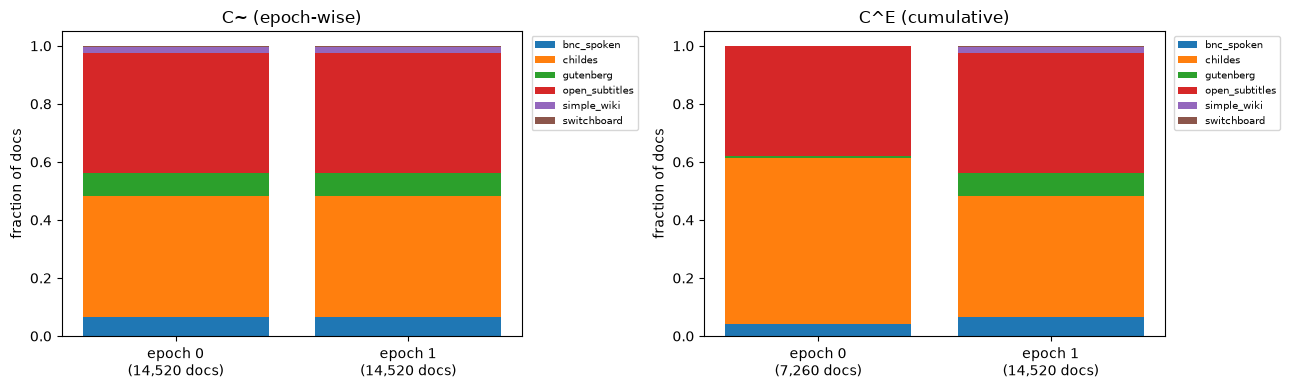

In [8]:
# Source mix comparison: C~ vs C^E side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, epoch_dir) in zip(axes, [("C~ (epoch-wise)", curr_dir), ("C^E (cumulative)", cum_dir)]):
    curr_path = Path(epoch_dir) / "curriculum"
    epoch_files = sorted(curr_path.glob("epoch_*.jsonl"))
    T_plot = len(epoch_files)

    mix = []
    sizes = []
    for p in epoch_files:
        ids_out = [json.loads(l)["id"] for l in p.read_text().splitlines()]
        sizes.append(len(ids_out))
        mix.append(Counter(i.split("#")[0] for i in ids_out))

    x = np.arange(T_plot)
    bottom = np.zeros(T_plot)
    for color, src in zip(colors, sources):
        vals = np.array([m.get(src, 0) / sizes[i] for i, m in enumerate(mix)])
        ax.bar(x, vals, bottom=bottom, label=src.replace(".train", ""), color=color)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([f"epoch {e}\n({sizes[e]:,} docs)" for e in range(T_plot)])
    ax.set_ylabel("fraction of docs")
    ax.set_title(label)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()